In [23]:
# ============================================================
# Deep Learning for Churn Prediction: ANN and CNN Models
# ============================================================

# ============================================================
# 1. Setup and Imports
# ============================================================

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.utils.class_weight import compute_class_weight
from sklearn.metrics import (
    classification_report, confusion_matrix,
    roc_auc_score, roc_curve, accuracy_score,
    precision_score, recall_score, f1_score
)

import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import callbacks
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import (
    Dense, Dropout, BatchNormalization,
    Conv1D, MaxPooling1D, Flatten, Input
)

import warnings
warnings.filterwarnings('ignore')

# Set seeds for reproducibility
np.random.seed(42)
tf.random.set_seed(42)

print("=" * 50)
print("TensorFlow version:", tf.__version__)
print("NumPy version:", np.__version__)
print("Pandas version:", pd.__version__)
print("=" * 50)

TensorFlow version: 2.21.0
NumPy version: 2.3.5
Pandas version: 2.3.3


In [24]:
# ============================================================
# 2. Load Preprocessed Data
# ============================================================

print("\n" + "=" * 50)
print("Loading Data")
print("=" * 50)

# Load features and target
X = pd.read_csv("X_features.csv")
y = pd.read_csv("y_target.csv").squeeze()  # convert single-column DataFrame to Series

print(f"Raw features shape : {X.shape}")
print(f"Target shape       : {y.shape}")
print(f"\nTarget distribution:")
print(y.value_counts())
print(f"\nTarget distribution (%):")
print(y.value_counts(normalize=True).mul(100).round(2).astype(str) + "%")
print(f"\nColumn names:\n{X.columns.tolist()}")
print(f"\nData types:\n{X.dtypes}")
print(f"\nMissing values:\n{X.isnull().sum()[X.isnull().sum() > 0]}")


Loading Data
Raw features shape : (90528, 19)
Target shape       : (90528,)

Target distribution:
Churn
0    49421
1    41107
Name: count, dtype: int64

Target distribution (%):
Churn
0    54.59%
1    45.41%
Name: proportion, dtype: object

Column names:
['customer_unique_id', 'customer_city', 'customer_state', 'purchased_approved', 'delivered_estimated', 'purchased_delivered', 'price', 'freight_value', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'geolocation_lat', 'geolocation_lng', 'payment_type', 'payment_installments', 'payment_value', 'Recency', 'Monetary']

Data types:
customer_unique_id       object
customer_city            object
customer_state           object
purchased_approved      float64
delivered_estimated     float64
purchased_delivered     float64
price                   float64
freight_value           float64
product_weight_g        float64
product_length_cm       float64
product_height_cm       float64
product_width_cm        flo

In [25]:
# ============================================================
# 3. Preprocessing Pipeline
# ============================================================

print("\n" + "=" * 50)
print("Preprocessing Pipeline")
print("=" * 50)

# ------------------------------------------------------------------
# Step 1: Drop identifier and high-cardinality columns
# ------------------------------------------------------------------
cols_to_drop = []

if 'customer_unique_id' in X.columns:
    cols_to_drop.append('customer_unique_id')
    print("Dropping: customer_unique_id (identifier)")

if 'customer_city' in X.columns:
    cols_to_drop.append('customer_city')
    print("Dropping: customer_city (high cardinality)")

if cols_to_drop:
    X.drop(columns=cols_to_drop, inplace=True)

# ------------------------------------------------------------------
# Step 2: Drop 'Recency' to prevent data leakage
# (Recency is used to construct the churn target label)
# ------------------------------------------------------------------
if 'Recency' in X.columns:
    X.drop(columns=['Recency'], inplace=True)
    print("Dropping: Recency (used to construct target → data leakage)")

# ------------------------------------------------------------------
# Step 3: Drop 'payment_value' if it duplicates 'Monetary'
# ------------------------------------------------------------------
if 'payment_value' in X.columns and 'Monetary' in X.columns:
    X.drop(columns=['payment_value'], inplace=True)
    print("Dropping: payment_value (duplicates Monetary)")

# ------------------------------------------------------------------
# Step 4: Encode 'customer_state' into Brazilian macro-regions
# ------------------------------------------------------------------
if 'customer_state' in X.columns:
    def encode_state_to_region(state):
        """Map Brazilian states to 5 macro-regions."""
        regions = {
            'southern':      ['RS', 'SC', 'PR'],
            'southeastern':  ['SP', 'RJ', 'MG', 'ES'],
            'centralwestern':['MT', 'MS', 'GO', 'DF'],
            'northeastern':  ['MA', 'PI', 'CE', 'RN', 'PB',
                              'PE', 'AL', 'SE', 'BA'],
        }
        for region, states in regions.items():
            if state in states:
                return region
        return 'northern'  # AM, PA, AC, RO, RR, AP, TO

    X['customer_state'] = X['customer_state'].apply(encode_state_to_region)
    print(f"Encoded customer_state → region counts:\n"
          f"{X['customer_state'].value_counts()}")
    X = pd.get_dummies(X, columns=['customer_state'], drop_first=True, dtype=int)
    print(f"One-hot encoded customer_state (drop_first=True)")

# ------------------------------------------------------------------
# Step 5: One-hot encode 'payment_type'
# ------------------------------------------------------------------
if 'payment_type' in X.columns:
    print(f"payment_type unique values: {X['payment_type'].unique()}")
    X = pd.get_dummies(X, columns=['payment_type'], drop_first=True, dtype=int)
    print("One-hot encoded payment_type (drop_first=True)")

# ------------------------------------------------------------------
# Step 6: Handle any remaining object columns
# ------------------------------------------------------------------
object_cols = X.select_dtypes(include=['object']).columns.tolist()
if object_cols:
    print(f"Warning: Remaining object columns → encoding: {object_cols}")
    X = pd.get_dummies(X, columns=object_cols, drop_first=True, dtype=int)

# ------------------------------------------------------------------
# Step 7: Handle missing values
# ------------------------------------------------------------------
if X.isnull().sum().sum() > 0:
    print(f"Filling {X.isnull().sum().sum()} missing values with column medians")
    X.fillna(X.median(), inplace=True)

print(f"\nFinal feature matrix shape : {X.shape}")
print(f"Final feature names:\n{X.columns.tolist()}")
print(f"\nData types after encoding:\n{X.dtypes.value_counts()}")


Preprocessing Pipeline
Dropping: customer_unique_id (identifier)
Dropping: customer_city (high cardinality)
Dropping: Recency (used to construct target → data leakage)
Dropping: payment_value (duplicates Monetary)
Encoded customer_state → region counts:
customer_state
southeastern      62218
southern          12963
northeastern       8553
centralwestern     5104
northern           1690
Name: count, dtype: int64
One-hot encoded customer_state (drop_first=True)
payment_type unique values: ['credit_card' 'boleto' 'voucher' 'debit_card']
One-hot encoded payment_type (drop_first=True)

Final feature matrix shape : (90528, 20)
Final feature names:
['purchased_approved', 'delivered_estimated', 'purchased_delivered', 'price', 'freight_value', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'geolocation_lat', 'geolocation_lng', 'payment_installments', 'Monetary', 'customer_state_northeastern', 'customer_state_northern', 'customer_state_southeastern', 'customer

In [26]:
# ============================================================
# 4. Train-Test Split
# ============================================================

print("\n" + "=" * 50)
print("Train-Test Split (80/20, stratified)")
print("=" * 50)

X_train, X_test, y_train, y_test = train_test_split(
    X, y,
    test_size=0.2,
    random_state=42,
    stratify=y          # preserve class distribution
)

# Reset indices to avoid alignment issues with numpy arrays
X_train = X_train.reset_index(drop=True)
X_test  = X_test.reset_index(drop=True)
y_train = y_train.reset_index(drop=True)
y_test  = y_test.reset_index(drop=True)

print(f"Training samples   : {X_train.shape[0]}")
print(f"Test samples       : {X_test.shape[0]}")
print(f"Number of features : {X_train.shape[1]}")

print(f"\nTrain target distribution:")
print(y_train.value_counts(normalize=True).mul(100).round(2))
print(f"\nTest target distribution:")
print(y_test.value_counts(normalize=True).mul(100).round(2))


Train-Test Split (80/20, stratified)
Training samples   : 72422
Test samples       : 18106
Number of features : 20

Train target distribution:
Churn
0    54.59
1    45.41
Name: proportion, dtype: float64

Test target distribution:
Churn
0    54.59
1    45.41
Name: proportion, dtype: float64


In [27]:
# ============================================================
# 5. Feature Scaling
# ============================================================

print("\n" + "=" * 50)
print("Standardizing Features")
print("=" * 50)

scaler = StandardScaler()

# Fit ONLY on training data to prevent data leakage
X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled  = scaler.transform(X_test)

# Keep feature names for later reference
feature_names = X.columns.tolist()

print(f"Scaler fitted on training set only.")
print(f"Train mean (first 3 features): "
      f"{scaler.mean_[:3].round(4)}")
print(f"Train std  (first 3 features): "
      f"{scaler.scale_[:3].round(4)}")
print(f"\nScaled train shape : {X_train_scaled.shape}")
print(f"Scaled test shape  : {X_test_scaled.shape}")


Standardizing Features
Scaler fitted on training set only.
Train mean (first 3 features): [ 0.0005 -0.0002  0.0025]
Train std  (first 3 features): [0.9987 1.0016 0.9992]

Scaled train shape : (72422, 20)
Scaled test shape  : (18106, 20)


In [28]:
# ============================================================
# 6. Class Weights
# ============================================================

print("\n" + "=" * 50)
print("Computing Class Weights")
print("=" * 50)

classes = np.unique(y_train)
class_weights_arr = compute_class_weight(
    class_weight='balanced',
    classes=classes,
    y=y_train
)
class_weight_dict = dict(zip(classes.astype(int), class_weights_arr))

print(f"Class labels    : {classes.tolist()}")
print(f"Class weights   : {class_weight_dict}")
print("(Weights > 1.0 upweight the minority class)")


Computing Class Weights
Class labels    : [0, 1]
Class weights   : {np.int64(0): np.float64(0.9158762677997825), np.int64(1): np.float64(1.1011403375399118)}
(Weights > 1.0 upweight the minority class)


In [29]:
# ============================================================
# 7. Artificial Neural Network (ANN)
# ============================================================

print("\n" + "=" * 50)
print("Building ANN Model")
print("=" * 50)

def build_ann(input_dim):
    """
    Multi-layer perceptron for binary churn classification.

    Architecture:
        Input → Dense(64, ReLU) → BN → Dropout(0.3)
              → Dense(32, ReLU) → BN → Dropout(0.3)
              → Dense(1, Sigmoid)
    """
    model = Sequential([
        Input(shape=(input_dim,)),

        Dense(64, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(32, activation='relu'),
        BatchNormalization(),
        Dropout(0.3),

        Dense(1, activation='sigmoid')
    ], name='ANN_Churn')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='ann_auc'),
            tf.keras.metrics.Precision(name='ann_precision'),
            tf.keras.metrics.Recall(name='ann_recall')
        ]
    )
    return model


ann_model = build_ann(input_dim=X_train_scaled.shape[1])
ann_model.summary()


Building ANN Model


Model: "ANN_Churn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ dense_5 (Dense)                      │ (None, 64)                  │           1,344 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_4                │ (None, 64)                  │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_3 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_6 (Dense)                      │ (None, 32)                  │           2,080 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_5                │ (None, 32)                  │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_4 (Dropout)                  │ (None, 32)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_7 (Dense)                      │ (None, 1)                   │              33 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 3,841 (15.00 KB)

 Trainable params: 3,649 (14.25 KB)

 Non-trainable params: 192 (768.00 B)

In [30]:
# ============================================================
# 7.1 ANN Callbacks
# ============================================================

ann_early_stop = callbacks.EarlyStopping(
    monitor='val_ann_auc',      # monitor AUC (better for imbalanced data)
    patience=10,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

ann_checkpoint = callbacks.ModelCheckpoint(
    filepath='ann_best.keras',
    monitor='val_ann_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

ann_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_ann_auc',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    mode='max',
    verbose=1
)

print("Callbacks configured:")
print(f"  EarlyStopping  : patience=10, monitor=val_ann_auc")
print(f"  ModelCheckpoint: saves best val_ann_auc to ann_best.keras")
print(f"  ReduceLROnPlateau: halves LR after 5 epochs of no improvement")

Callbacks configured:
  EarlyStopping  : patience=10, monitor=val_ann_auc
  ModelCheckpoint: saves best val_ann_auc to ann_best.keras
  ReduceLROnPlateau: halves LR after 5 epochs of no improvement


In [31]:
# ============================================================
# 7.2 ANN Training
# ============================================================

print("\n" + "=" * 50)
print("Training ANN")
print("=" * 50)

history_ann = ann_model.fit(
    X_train_scaled, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[ann_early_stop, ann_checkpoint, ann_reduce_lr],
    verbose=1
)

print(f"\nTraining stopped at epoch: {len(history_ann.history['loss'])}")


Training ANN
Epoch 1/100
895/906 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.5349 - ann_auc: 0.5487 - ann_precision: 0.4907 - ann_recall: 0.5338 - loss: 0.7826
Epoch 1: val_ann_auc improved from None to 0.66069, saving model to ann_best.keras

Epoch 1: finished saving model to ann_best.keras
906/906 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.5557 - ann_auc: 0.5765 - ann_precision: 0.5094 - ann_recall: 0.5552 - loss: 0.7215 - val_accuracy: 0.6109 - val_ann_auc: 0.6607 - val_ann_precision: 0.5670 - val_ann_recall: 0.6204 - val_loss: 0.6486 - learning_rate: 0.0010
Epoch 2/100
901/906 ━━━━━━━━━━━━━━━━━━━━ 0s 4ms/step - accuracy: 0.6009 - ann_auc: 0.6410 - ann_precision: 0.5558 - ann_recall: 0.6214 - loss: 0.6602
Epoch 2: val_ann_auc improved from 0.66069 to 0.68243, saving model to ann_best.keras

Epoch 2: finished saving model to ann_best.keras
906/906 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6034 - ann_auc: 0.6491 - ann_precision: 0.5549 - ann_recall: 0.6351 - loss: 0.655

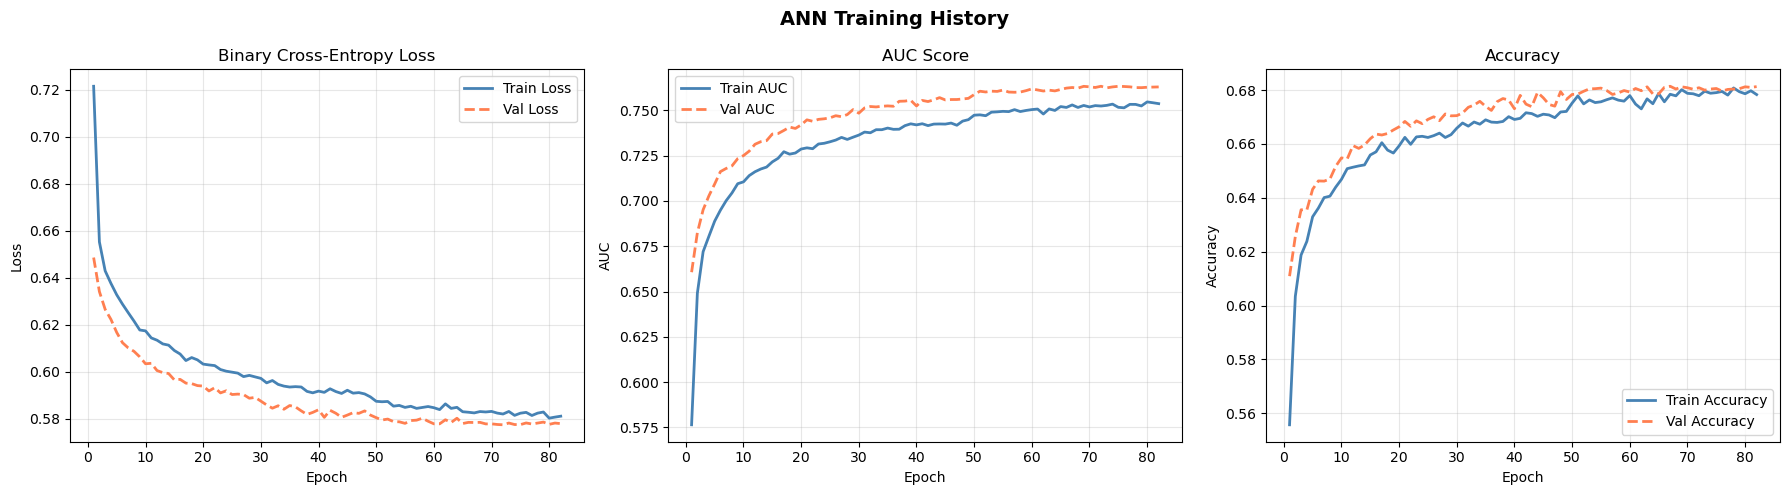

Saved: ann_training_curves.png


In [33]:
# ============================================================
# 7.3 ANN Training Curves
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('ANN Training History', fontsize=14, fontweight='bold')

epochs_ran = range(1, len(history_ann.history['loss']) + 1)

# --- Loss ---
axes[0].plot(epochs_ran, history_ann.history['loss'],
             label='Train Loss', color='steelblue', linewidth=2)
axes[0].plot(epochs_ran, history_ann.history['val_loss'],
             label='Val Loss', color='coral', linewidth=2, linestyle='--')
axes[0].set_title('Binary Cross-Entropy Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- AUC ---
axes[1].plot(epochs_ran, history_ann.history['ann_auc'],
             label='Train AUC', color='steelblue', linewidth=2)
axes[1].plot(epochs_ran, history_ann.history['val_ann_auc'],
             label='Val AUC', color='coral', linewidth=2, linestyle='--')
axes[1].set_title('AUC Score')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# --- Accuracy ---
axes[2].plot(epochs_ran, history_ann.history['accuracy'],
             label='Train Accuracy', color='steelblue', linewidth=2)
axes[2].plot(epochs_ran, history_ann.history['val_accuracy'],
             label='Val Accuracy', color='coral', linewidth=2, linestyle='--')
axes[2].set_title('Accuracy')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('ann_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ann_training_curves.png")


ANN Evaluation on Test Set

Metric             Score
-------------------------
Accuracy          0.6831
Precision         0.6212
Recall            0.7744
F1 Score          0.6894
AUC-ROC           0.7621

Detailed Classification Report:
               precision    recall  f1-score   support

Non-Churn (0)       0.76      0.61      0.68      9884
    Churn (1)       0.62      0.77      0.69      8222

     accuracy                           0.68     18106
    macro avg       0.69      0.69      0.68     18106
 weighted avg       0.70      0.68      0.68     18106



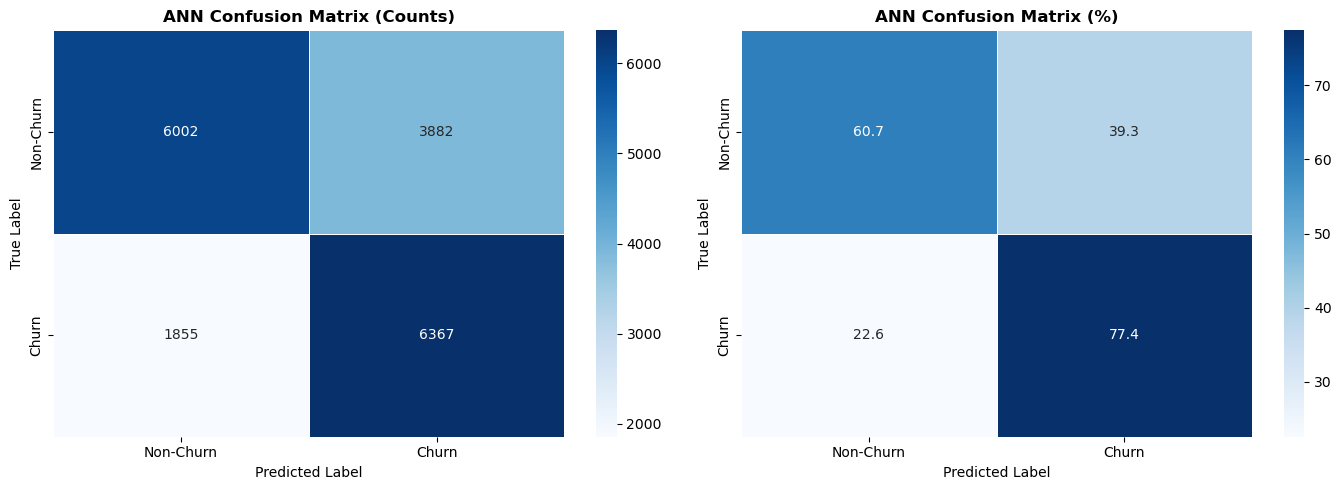

Saved: ann_confusion_matrix.png


In [34]:
# ============================================================
# 7.4 ANN Evaluation
# ============================================================

print("\n" + "=" * 50)
print("ANN Evaluation on Test Set")
print("=" * 50)

# Predictions
y_pred_prob_ann = ann_model.predict(X_test_scaled, verbose=0).ravel()
y_pred_ann      = (y_pred_prob_ann >= 0.5).astype(int)

# Metrics
acc_ann  = accuracy_score(y_test, y_pred_ann)
prec_ann = precision_score(y_test, y_pred_ann, zero_division=0)
rec_ann  = recall_score(y_test, y_pred_ann, zero_division=0)
f1_ann   = f1_score(y_test, y_pred_ann, zero_division=0)
auc_ann  = roc_auc_score(y_test, y_pred_prob_ann)

print(f"\n{'Metric':<15} {'Score':>8}")
print("-" * 25)
print(f"{'Accuracy':<15} {acc_ann:>8.4f}")
print(f"{'Precision':<15} {prec_ann:>8.4f}")
print(f"{'Recall':<15} {rec_ann:>8.4f}")
print(f"{'F1 Score':<15} {f1_ann:>8.4f}")
print(f"{'AUC-ROC':<15} {auc_ann:>8.4f}")

print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_ann,
                             target_names=['Non-Churn (0)', 'Churn (1)']))

# --- Confusion Matrix ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_ann = confusion_matrix(y_test, y_pred_ann)
cm_ann_pct = cm_ann.astype(float) / cm_ann.sum(axis=1, keepdims=True) * 100

sns.heatmap(cm_ann, annot=True, fmt='d', cmap='Blues',
            xticklabels=['Non-Churn', 'Churn'],
            yticklabels=['Non-Churn', 'Churn'],
            ax=axes[0], linewidths=0.5)
axes[0].set_title('ANN Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_ann_pct, annot=True, fmt='.1f', cmap='Blues',
            xticklabels=['Non-Churn', 'Churn'],
            yticklabels=['Non-Churn', 'Churn'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('ANN Confusion Matrix (%)', fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('ann_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ann_confusion_matrix.png")

In [35]:
# ============================================================
# 8. 1D Convolutional Neural Network (CNN)
# ============================================================

print("\n" + "=" * 50)
print("Building CNN Model")
print("=" * 50)

# Note on using CNN for tabular data:
# -----------------------------------------------
# 1D CNNs are not natively designed for tabular data where feature
# order is arbitrary. However, by grouping semantically related
# features together (RFM → payment → order → region), the CNN can
# detect local patterns across adjacent related features.
# This serves as a useful architectural comparison.
# -----------------------------------------------

# -- Reorder features into semantic groups for CNN --
rfm_cols      = [c for c in feature_names if c in ['Frequency', 'Monetary']]
order_cols    = [c for c in feature_names if any(
                    kw in c.lower() for kw in
                    ['order', 'review', 'delivery', 'freight', 'items'])]
payment_cols  = [c for c in feature_names if 'payment' in c.lower()]
region_cols   = [c for c in feature_names if 'customer_state' in c.lower()]
other_cols    = [c for c in feature_names
                 if c not in rfm_cols + order_cols + payment_cols + region_cols]

ordered_cols = rfm_cols + order_cols + payment_cols + region_cols + other_cols

# Verify no columns are lost
assert len(ordered_cols) == len(feature_names), \
    f"Column count mismatch: {len(ordered_cols)} vs {len(feature_names)}"

print(f"Feature grouping for CNN input:")
print(f"  RFM features      : {rfm_cols}")
print(f"  Order features    : {order_cols}")
print(f"  Payment features  : {payment_cols}")
print(f"  Region features   : {region_cols}")
print(f"  Other features    : {other_cols}")
print(f"  Total             : {len(ordered_cols)} features")

# -- Reorder the scaled arrays --
# Convert to DataFrame, reorder, then back to numpy
X_train_df = pd.DataFrame(X_train_scaled, columns=feature_names)
X_test_df  = pd.DataFrame(X_test_scaled,  columns=feature_names)

X_train_ordered = X_train_df[ordered_cols].values
X_test_ordered  = X_test_df[ordered_cols].values

# -- Reshape for CNN: (samples, timesteps/features, channels) --
n_features = X_train_ordered.shape[1]
X_train_cnn = X_train_ordered.reshape(-1, n_features, 1)
X_test_cnn  = X_test_ordered.reshape(-1, n_features, 1)

print(f"\nCNN input shape (train) : {X_train_cnn.shape}")
print(f"CNN input shape (test)  : {X_test_cnn.shape}")


Building CNN Model
Feature grouping for CNN input:
  RFM features      : ['Monetary']
  Order features    : ['freight_value']
  Payment features  : ['payment_installments', 'payment_type_credit_card', 'payment_type_debit_card', 'payment_type_voucher']
  Region features   : ['customer_state_northeastern', 'customer_state_northern', 'customer_state_southeastern', 'customer_state_southern']
  Other features    : ['purchased_approved', 'delivered_estimated', 'purchased_delivered', 'price', 'product_weight_g', 'product_length_cm', 'product_height_cm', 'product_width_cm', 'geolocation_lat', 'geolocation_lng']
  Total             : 20 features

CNN input shape (train) : (72422, 20, 1)
CNN input shape (test)  : (18106, 20, 1)


In [36]:
# ============================================================
# 8.1 CNN Architecture
# ============================================================

def build_cnn(input_shape):
    """
    1D CNN for binary churn classification on tabular data.

    Architecture:
        Input → Conv1D(32) → BN → MaxPool
              → Conv1D(64) → BN → MaxPool
              → Flatten
              → Dense(64, ReLU) → Dropout(0.5)
              → Dense(1, Sigmoid)
    """
    model = Sequential([
        Input(shape=input_shape),

        # Block 1
        Conv1D(filters=32, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        # Block 2
        Conv1D(filters=64, kernel_size=3, activation='relu', padding='same'),
        BatchNormalization(),
        MaxPooling1D(pool_size=2),

        # Classifier head
        Flatten(),
        Dense(64, activation='relu'),
        Dropout(0.5),
        Dense(1, activation='sigmoid')

    ], name='CNN_Churn')

    model.compile(
        optimizer=keras.optimizers.Adam(learning_rate=1e-3),
        loss='binary_crossentropy',
        metrics=[
            'accuracy',
            tf.keras.metrics.AUC(name='cnn_auc'),
            tf.keras.metrics.Precision(name='cnn_precision'),
            tf.keras.metrics.Recall(name='cnn_recall')
        ]
    )
    return model


cnn_model = build_cnn(input_shape=(n_features, 1))
cnn_model.summary()

Model: "CNN_Churn"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv1d_2 (Conv1D)                    │ (None, 20, 32)              │             128 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_6                │ (None, 20, 32)              │             128 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_2 (MaxPooling1D)       │ (None, 10, 32)              │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv1d_3 (Conv1D)                    │ (None, 10, 64)              │           6,208 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ batch_normalization_7                │ (None, 10, 64)              │             256 │
│ (BatchNormalization)                 │                             │                 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling1d_3 (MaxPooling1D)       │ (None, 5, 64)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten_1 (Flatten)                  │ (None, 320)                 │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_8 (Dense)                      │ (None, 64)                  │          20,544 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dropout_5 (Dropout)                  │ (None, 64)                  │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_9 (Dense)                      │ (None, 1)                   │              65 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 27,329 (106.75 KB)

 Trainable params: 27,137 (106.00 KB)

 Non-trainable params: 192 (768.00 B)

In [37]:
# ============================================================
# 8.2 CNN Callbacks
# ============================================================

cnn_early_stop = callbacks.EarlyStopping(
    monitor='val_cnn_auc',
    patience=10,
    restore_best_weights=True,
    mode='max',
    verbose=1
)

cnn_checkpoint = callbacks.ModelCheckpoint(
    filepath='cnn_best.keras',
    monitor='val_cnn_auc',
    mode='max',
    save_best_only=True,
    verbose=1
)

cnn_reduce_lr = callbacks.ReduceLROnPlateau(
    monitor='val_cnn_auc',
    factor=0.5,
    patience=5,
    min_lr=1e-6,
    mode='max',
    verbose=1
)

print("CNN callbacks configured.")

CNN callbacks configured.


In [38]:
# ============================================================
# 8.3 CNN Training
# ============================================================

print("\n" + "=" * 50)
print("Training CNN")
print("=" * 50)

history_cnn = cnn_model.fit(
    X_train_cnn, y_train,
    validation_split=0.2,
    epochs=100,
    batch_size=64,
    class_weight=class_weight_dict,
    callbacks=[cnn_early_stop, cnn_checkpoint, cnn_reduce_lr],
    verbose=1
)

print(f"\nTraining stopped at epoch: {len(history_cnn.history['loss'])}")


Training CNN
Epoch 1/100
906/906 ━━━━━━━━━━━━━━━━━━━━ 0s 8ms/step - accuracy: 0.5756 - cnn_auc: 0.6061 - cnn_precision: 0.5311 - cnn_recall: 0.5916 - loss: 0.7067
Epoch 1: val_cnn_auc improved from None to 0.69139, saving model to cnn_best.keras

Epoch 1: finished saving model to cnn_best.keras
906/906 ━━━━━━━━━━━━━━━━━━━━ 12s 11ms/step - accuracy: 0.5975 - cnn_auc: 0.6386 - cnn_precision: 0.5503 - cnn_recall: 0.6157 - loss: 0.6656 - val_accuracy: 0.6315 - val_cnn_auc: 0.6914 - val_cnn_precision: 0.5806 - val_cnn_recall: 0.6911 - val_loss: 0.6321 - learning_rate: 0.0010
Epoch 2/100
900/906 ━━━━━━━━━━━━━━━━━━━━ 0s 9ms/step - accuracy: 0.6303 - cnn_auc: 0.6865 - cnn_precision: 0.5830 - cnn_recall: 0.6640 - loss: 0.6333
Epoch 2: val_cnn_auc improved from 0.69139 to 0.71104, saving model to cnn_best.keras

Epoch 2: finished saving model to cnn_best.keras
906/906 ━━━━━━━━━━━━━━━━━━━━ 10s 11ms/step - accuracy: 0.6328 - cnn_auc: 0.6902 - cnn_precision: 0.5835 - cnn_recall: 0.6656 - loss: 0.6

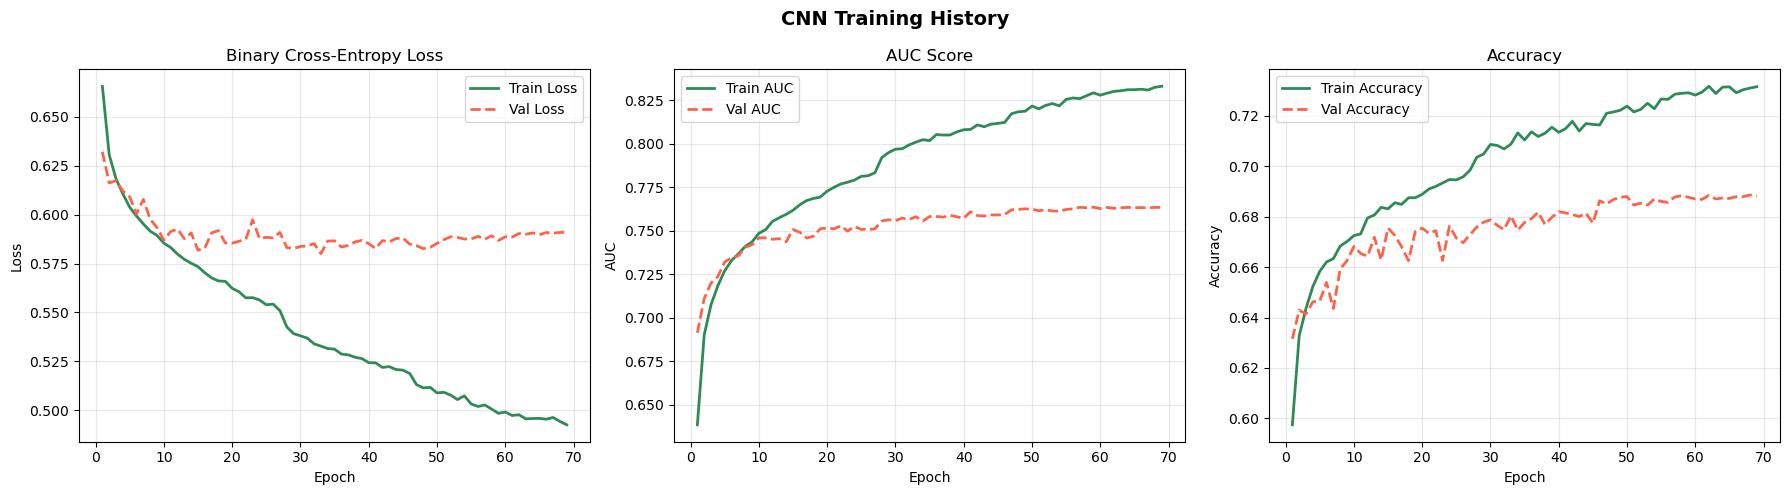

Saved: cnn_training_curves.png


In [39]:
# ============================================================
# 8.4 CNN Training Curves
# ============================================================

fig, axes = plt.subplots(1, 3, figsize=(18, 5))
fig.suptitle('CNN Training History', fontsize=14, fontweight='bold')

epochs_ran_cnn = range(1, len(history_cnn.history['loss']) + 1)

# --- Loss ---
axes[0].plot(epochs_ran_cnn, history_cnn.history['loss'],
             label='Train Loss', color='seagreen', linewidth=2)
axes[0].plot(epochs_ran_cnn, history_cnn.history['val_loss'],
             label='Val Loss', color='tomato', linewidth=2, linestyle='--')
axes[0].set_title('Binary Cross-Entropy Loss')
axes[0].set_xlabel('Epoch')
axes[0].set_ylabel('Loss')
axes[0].legend()
axes[0].grid(True, alpha=0.3)

# --- AUC ---
axes[1].plot(epochs_ran_cnn, history_cnn.history['cnn_auc'],
             label='Train AUC', color='seagreen', linewidth=2)
axes[1].plot(epochs_ran_cnn, history_cnn.history['val_cnn_auc'],
             label='Val AUC', color='tomato', linewidth=2, linestyle='--')
axes[1].set_title('AUC Score')
axes[1].set_xlabel('Epoch')
axes[1].set_ylabel('AUC')
axes[1].legend()
axes[1].grid(True, alpha=0.3)

# --- Accuracy ---
axes[2].plot(epochs_ran_cnn, history_cnn.history['accuracy'],
             label='Train Accuracy', color='seagreen', linewidth=2)
axes[2].plot(epochs_ran_cnn, history_cnn.history['val_accuracy'],
             label='Val Accuracy', color='tomato', linewidth=2, linestyle='--')
axes[2].set_title('Accuracy')
axes[2].set_xlabel('Epoch')
axes[2].set_ylabel('Accuracy')
axes[2].legend()
axes[2].grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('cnn_training_curves.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cnn_training_curves.png")


CNN Evaluation on Test Set

Metric             Score
-------------------------
Accuracy          0.6850
Precision         0.6324
Recall            0.7316
F1 Score          0.6784
AUC-ROC           0.7656

Detailed Classification Report:
               precision    recall  f1-score   support

Non-Churn (0)       0.74      0.65      0.69      9884
    Churn (1)       0.63      0.73      0.68      8222

     accuracy                           0.69     18106
    macro avg       0.69      0.69      0.68     18106
 weighted avg       0.69      0.69      0.69     18106



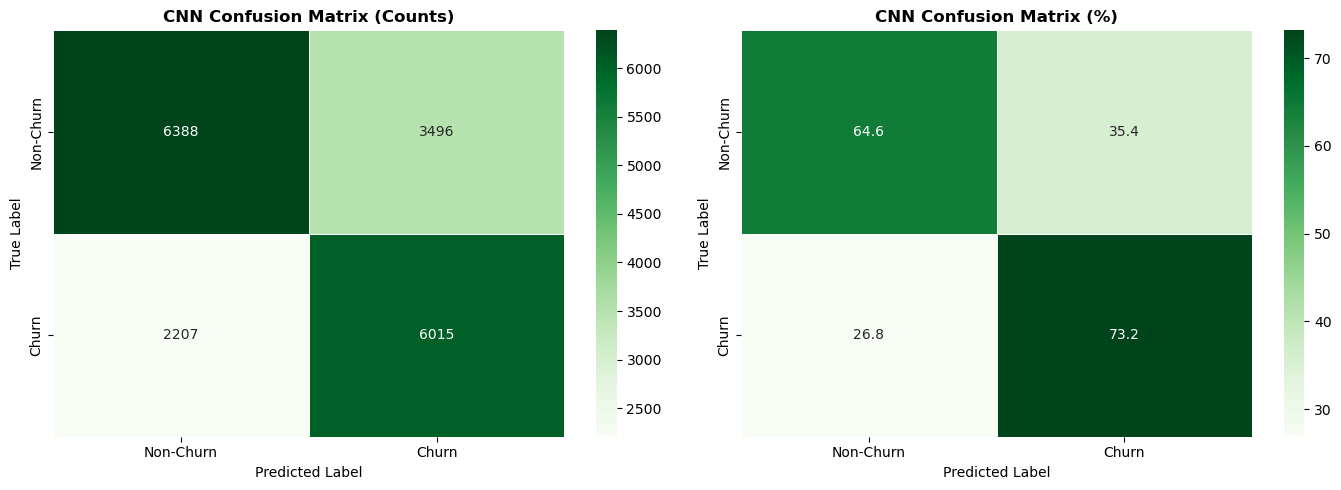

Saved: cnn_confusion_matrix.png


In [40]:
# ============================================================
# 8.5 CNN Evaluation
# ============================================================

print("\n" + "=" * 50)
print("CNN Evaluation on Test Set")
print("=" * 50)

# Predictions
y_pred_prob_cnn = cnn_model.predict(X_test_cnn, verbose=0).ravel()
y_pred_cnn      = (y_pred_prob_cnn >= 0.5).astype(int)

# Metrics
acc_cnn  = accuracy_score(y_test, y_pred_cnn)
prec_cnn = precision_score(y_test, y_pred_cnn, zero_division=0)
rec_cnn  = recall_score(y_test, y_pred_cnn, zero_division=0)
f1_cnn   = f1_score(y_test, y_pred_cnn, zero_division=0)
auc_cnn  = roc_auc_score(y_test, y_pred_prob_cnn)

print(f"\n{'Metric':<15} {'Score':>8}")
print("-" * 25)
print(f"{'Accuracy':<15} {acc_cnn:>8.4f}")
print(f"{'Precision':<15} {prec_cnn:>8.4f}")
print(f"{'Recall':<15} {rec_cnn:>8.4f}")
print(f"{'F1 Score':<15} {f1_cnn:>8.4f}")
print(f"{'AUC-ROC':<15} {auc_cnn:>8.4f}")

print(f"\nDetailed Classification Report:")
print(classification_report(y_test, y_pred_cnn,
                             target_names=['Non-Churn (0)', 'Churn (1)']))

# --- Confusion Matrix ---
fig, axes = plt.subplots(1, 2, figsize=(14, 5))

cm_cnn = confusion_matrix(y_test, y_pred_cnn)
cm_cnn_pct = cm_cnn.astype(float) / cm_cnn.sum(axis=1, keepdims=True) * 100

sns.heatmap(cm_cnn, annot=True, fmt='d', cmap='Greens',
            xticklabels=['Non-Churn', 'Churn'],
            yticklabels=['Non-Churn', 'Churn'],
            ax=axes[0], linewidths=0.5)
axes[0].set_title('CNN Confusion Matrix (Counts)', fontweight='bold')
axes[0].set_xlabel('Predicted Label')
axes[0].set_ylabel('True Label')

sns.heatmap(cm_cnn_pct, annot=True, fmt='.1f', cmap='Greens',
            xticklabels=['Non-Churn', 'Churn'],
            yticklabels=['Non-Churn', 'Churn'],
            ax=axes[1], linewidths=0.5)
axes[1].set_title('CNN Confusion Matrix (%)', fontweight='bold')
axes[1].set_xlabel('Predicted Label')
axes[1].set_ylabel('True Label')

plt.tight_layout()
plt.savefig('cnn_confusion_matrix.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: cnn_confusion_matrix.png")


ROC Curve Comparison


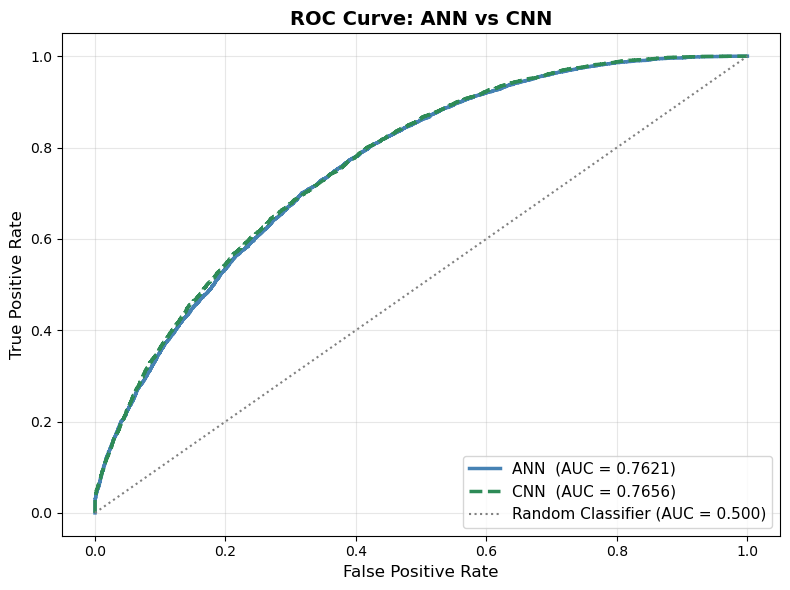

Saved: roc_curve_comparison.png


In [41]:
# ============================================================
# 9. ROC Curves - ANN vs CNN (Combined Plot)
# ============================================================

print("\n" + "=" * 50)
print("ROC Curve Comparison")
print("=" * 50)

fpr_ann, tpr_ann, thresholds_ann = roc_curve(y_test, y_pred_prob_ann)
fpr_cnn, tpr_cnn, thresholds_cnn = roc_curve(y_test, y_pred_prob_cnn)

plt.figure(figsize=(8, 6))

plt.plot(fpr_ann, tpr_ann,
         label=f'ANN  (AUC = {auc_ann:.4f})',
         color='steelblue', linewidth=2.5)

plt.plot(fpr_cnn, tpr_cnn,
         label=f'CNN  (AUC = {auc_cnn:.4f})',
         color='seagreen', linewidth=2.5, linestyle='--')

plt.plot([0, 1], [0, 1],
         label='Random Classifier (AUC = 0.500)',
         color='gray', linewidth=1.5, linestyle=':')

plt.xlabel('False Positive Rate', fontsize=12)
plt.ylabel('True Positive Rate', fontsize=12)
plt.title('ROC Curve: ANN vs CNN', fontsize=14, fontweight='bold')
plt.legend(loc='lower right', fontsize=11)
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('roc_curve_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: roc_curve_comparison.png")

In [42]:
# ============================================================
# 10. Permutation Feature Importance (ANN)
# ============================================================

print("\n" + "=" * 50)
print("Permutation Feature Importance - ANN")
print("=" * 50)

def permutation_importance_dl(model, X_val_arr, y_val_arr,
                               feature_names, n_repeats=5,
                               predict_fn=None):
    """
    Compute permutation importance for a Keras model.

    For each feature:
      1. Shuffle that feature's values across all samples.
      2. Measure the drop in AUC vs baseline.
      3. Repeat n_repeats times and average.

    Parameters
    ----------
    model        : Keras model
    X_val_arr    : np.ndarray, shape (n_samples, n_features)
    y_val_arr    : np.ndarray, shape (n_samples,)
    feature_names: list of str
    n_repeats    : int, number of shuffle repeats per feature
    predict_fn   : optional callable; defaults to model.predict

    Returns
    -------
    pd.DataFrame with columns ['Feature', 'Importance_Mean', 'Importance_Std']
    """
    if predict_fn is None:
        predict_fn = lambda X: model.predict(X, verbose=0).ravel()

    # Baseline AUC on unshuffled data
    baseline_auc = roc_auc_score(y_val_arr, predict_fn(X_val_arr))
    print(f"Baseline AUC: {baseline_auc:.4f}")

    results = []
    total = len(feature_names)

    for i, feat in enumerate(feature_names):
        drops = []
        for _ in range(n_repeats):
            X_perm = X_val_arr.copy()
            # Correct: permute only column i (not shuffle rows)
            X_perm[:, i] = np.random.permutation(X_perm[:, i])
            perm_auc = roc_auc_score(y_val_arr, predict_fn(X_perm))
            drops.append(baseline_auc - perm_auc)

        results.append({
            'Feature':          feat,
            'Importance_Mean':  np.mean(drops),
            'Importance_Std':   np.std(drops)
        })

        if (i + 1) % 5 == 0 or (i + 1) == total:
            print(f"  Processed {i + 1}/{total} features...")

    imp_df = pd.DataFrame(results).sort_values('Importance_Mean', ascending=False)
    imp_df = imp_df.reset_index(drop=True)
    return imp_df


# Run permutation importance on the test set
imp_df_ann = permutation_importance_dl(
    model=ann_model,
    X_val_arr=X_test_scaled,
    y_val_arr=y_test.values,
    feature_names=feature_names,
    n_repeats=5
)

print(f"\nTop 10 most important features (ANN):")
print(imp_df_ann.head(10).to_string(index=False))


Permutation Feature Importance - ANN
Baseline AUC: 0.7621
  Processed 5/20 features...
  Processed 10/20 features...
  Processed 15/20 features...
  Processed 20/20 features...

Top 10 most important features (ANN):
                 Feature  Importance_Mean  Importance_Std
           freight_value         0.120192        0.003135
     delivered_estimated         0.111754        0.001716
     purchased_delivered         0.102452        0.002387
      purchased_approved         0.061881        0.002288
         geolocation_lat         0.038674        0.002048
        product_weight_g         0.032993        0.000983
payment_type_credit_card         0.032102        0.001271
                Monetary         0.027739        0.000887
         geolocation_lng         0.022625        0.001114
                   price         0.019998        0.002153


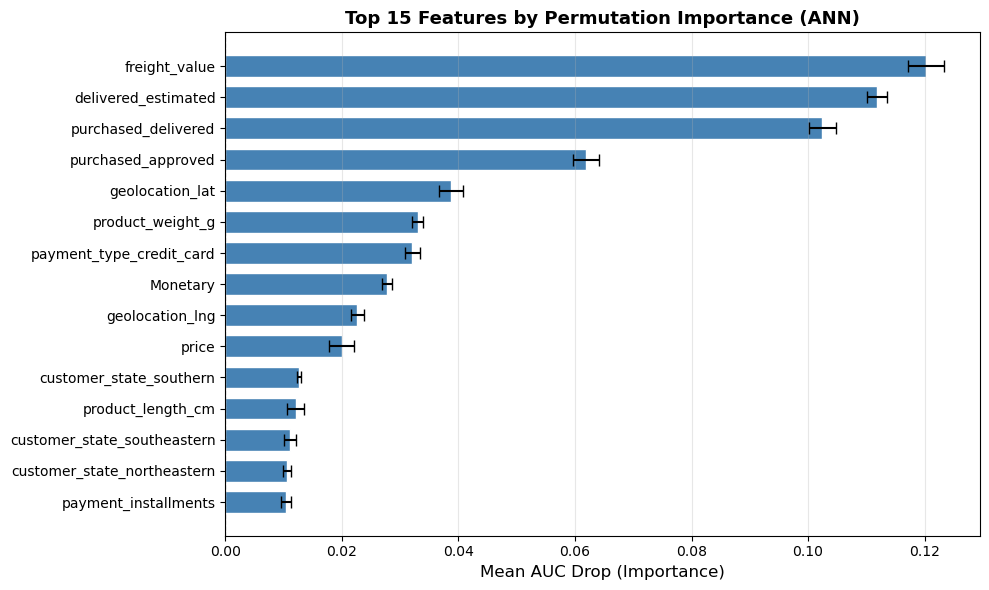

Saved: ann_feature_importance.png


In [43]:
# ============================================================
# 10.1 Plot Feature Importance
# ============================================================

top_n = min(15, len(imp_df_ann))
top_features = imp_df_ann.head(top_n)

plt.figure(figsize=(10, 6))

bars = plt.barh(
    top_features['Feature'][::-1],
    top_features['Importance_Mean'][::-1],
    xerr=top_features['Importance_Std'][::-1],
    color=['steelblue' if v >= 0 else 'tomato'
           for v in top_features['Importance_Mean'][::-1]],
    edgecolor='white',
    capsize=4,
    height=0.7
)

plt.axvline(x=0, color='black', linewidth=0.8, linestyle='--')
plt.xlabel('Mean AUC Drop (Importance)', fontsize=12)
plt.title(f'Top {top_n} Features by Permutation Importance (ANN)',
          fontsize=13, fontweight='bold')
plt.grid(True, axis='x', alpha=0.3)
plt.tight_layout()
plt.savefig('ann_feature_importance.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ann_feature_importance.png")


Threshold Optimization (ANN)
Best threshold : 0.43
Best F1 Score  : 0.6995

ANN with threshold = 0.43:
  Accuracy  : 0.6530
  Precision : 0.5764
  Recall    : 0.8896
  F1 Score  : 0.6995


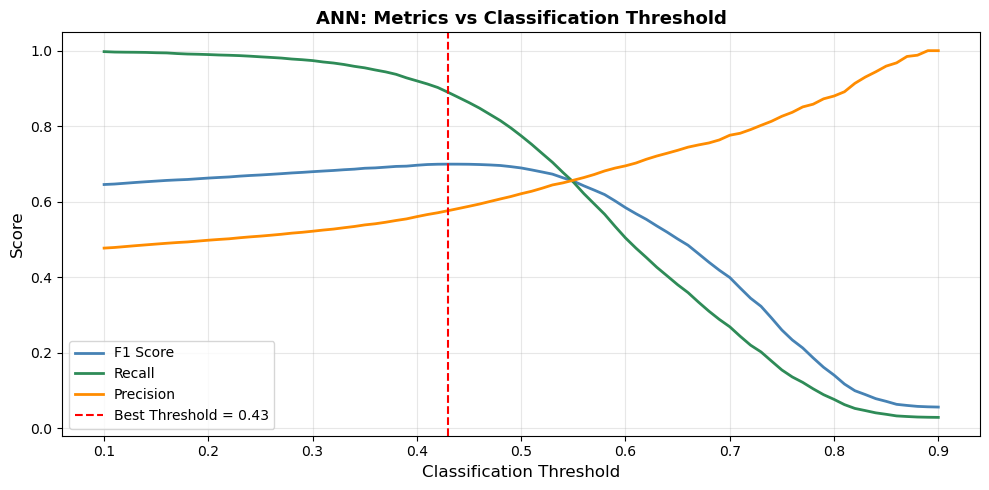

Saved: ann_threshold_optimization.png


In [44]:
# ============================================================
# 11. Threshold Optimization
# ============================================================

print("\n" + "=" * 50)
print("Threshold Optimization (ANN)")
print("=" * 50)

# Find the threshold that maximizes F1 score on test set
thresholds = np.arange(0.10, 0.91, 0.01)
f1_scores  = []
rec_scores = []
pre_scores = []

for thresh in thresholds:
    preds = (y_pred_prob_ann >= thresh).astype(int)
    f1_scores.append(f1_score(y_test, preds, zero_division=0))
    rec_scores.append(recall_score(y_test, preds, zero_division=0))
    pre_scores.append(precision_score(y_test, preds, zero_division=0))

best_thresh_idx = np.argmax(f1_scores)
best_threshold  = thresholds[best_thresh_idx]
best_f1         = f1_scores[best_thresh_idx]

print(f"Best threshold : {best_threshold:.2f}")
print(f"Best F1 Score  : {best_f1:.4f}")

# Recalculate metrics with optimal threshold
y_pred_ann_opt  = (y_pred_prob_ann >= best_threshold).astype(int)
acc_ann_opt     = accuracy_score(y_test, y_pred_ann_opt)
prec_ann_opt    = precision_score(y_test, y_pred_ann_opt, zero_division=0)
rec_ann_opt     = recall_score(y_test, y_pred_ann_opt, zero_division=0)
f1_ann_opt      = f1_score(y_test, y_pred_ann_opt, zero_division=0)

print(f"\nANN with threshold = {best_threshold:.2f}:")
print(f"  Accuracy  : {acc_ann_opt:.4f}")
print(f"  Precision : {prec_ann_opt:.4f}")
print(f"  Recall    : {rec_ann_opt:.4f}")
print(f"  F1 Score  : {f1_ann_opt:.4f}")

# Plot threshold vs metrics
plt.figure(figsize=(10, 5))
plt.plot(thresholds, f1_scores,  label='F1 Score',  color='steelblue',  linewidth=2)
plt.plot(thresholds, rec_scores, label='Recall',    color='seagreen',   linewidth=2)
plt.plot(thresholds, pre_scores, label='Precision', color='darkorange', linewidth=2)
plt.axvline(x=best_threshold, color='red', linestyle='--', linewidth=1.5,
            label=f'Best Threshold = {best_threshold:.2f}')
plt.xlabel('Classification Threshold', fontsize=12)
plt.ylabel('Score', fontsize=12)
plt.title('ANN: Metrics vs Classification Threshold', fontsize=13, fontweight='bold')
plt.legend()
plt.grid(True, alpha=0.3)
plt.tight_layout()
plt.savefig('ann_threshold_optimization.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: ann_threshold_optimization.png")

In [45]:
# ============================================================
# 12. Full Model Comparison
# ============================================================

print("\n" + "=" * 50)
print("Full Model Comparison")
print("=" * 50)

# Load XGBoost metrics from Notebook 4 if available,
# otherwise use documented approximate values
try:
    xgb_metrics_df = pd.read_csv("xgboost_best_metrics.csv")
    xgb_acc  = float(xgb_metrics_df['accuracy'].iloc[0])
    xgb_prec = float(xgb_metrics_df['precision'].iloc[0])
    xgb_rec  = float(xgb_metrics_df['recall'].iloc[0])
    xgb_f1   = float(xgb_metrics_df['f1'].iloc[0])
    xgb_auc  = float(xgb_metrics_df['auc'].iloc[0])
    print("Loaded XGBoost metrics from xgboost_best_metrics.csv")
except FileNotFoundError:
    # Values from Notebook 4 (XGBoost + RFE)
    xgb_acc, xgb_prec, xgb_rec, xgb_f1, xgb_auc = (
        0.7617, 0.7286, 0.7613, 0.7440, 0.8400
    )
    print("Warning: xgboost_best_metrics.csv not found.")
    print("Using documented approximate values from Notebook 4.")

results = pd.DataFrame({
    'Model': [
        'ANN (thresh=0.50)',
        f'ANN (thresh={best_threshold:.2f})',
        'CNN (thresh=0.50)',
        'XGBoost + RFE (NB4)'
    ],
    'Accuracy':  [acc_ann,  acc_ann_opt,  acc_cnn,  xgb_acc],
    'Precision': [prec_ann, prec_ann_opt, prec_cnn, xgb_prec],
    'Recall':    [rec_ann,  rec_ann_opt,  rec_cnn,  xgb_rec],
    'F1 Score':  [f1_ann,   f1_ann_opt,   f1_cnn,   xgb_f1],
    'AUC-ROC':   [auc_ann,  auc_ann,      auc_cnn,  xgb_auc]
})

# Print table
print(f"\n{results.to_string(index=False)}")

# Save results
results.to_csv("deep_learning_results.csv", index=False)
print("\nSaved: deep_learning_results.csv")


Full Model Comparison
Using documented approximate values from Notebook 4.

              Model  Accuracy  Precision   Recall  F1 Score  AUC-ROC
  ANN (thresh=0.50)  0.683144   0.621231 0.774386  0.689405 0.762089
  ANN (thresh=0.43)  0.652988   0.576405 0.889565  0.699536 0.762089
  CNN (thresh=0.50)  0.685022   0.632426 0.731574  0.678396 0.765612
XGBoost + RFE (NB4)  0.761700   0.728600 0.761300  0.744000 0.840000

Saved: deep_learning_results.csv


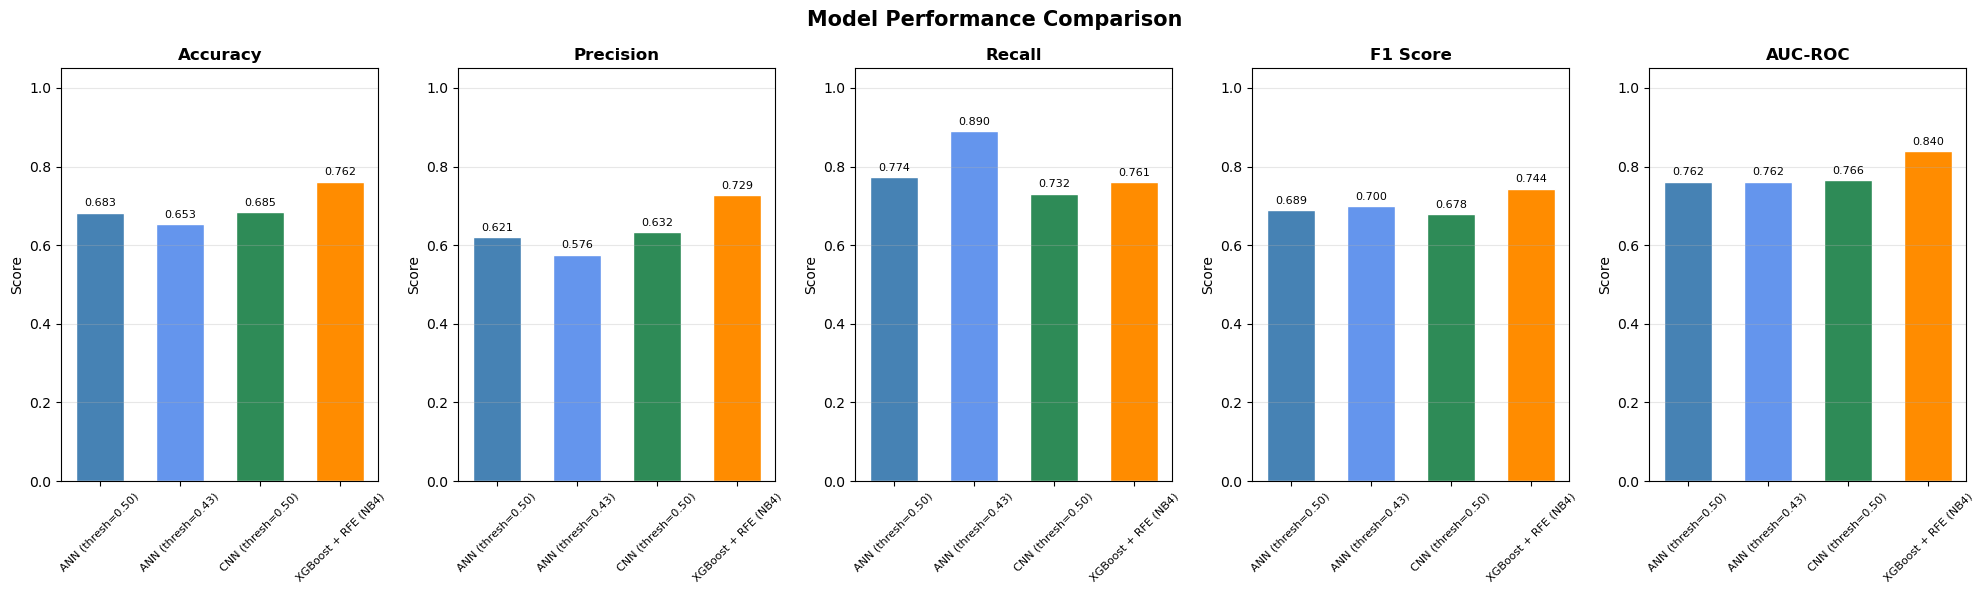

Saved: model_comparison.png


In [46]:
# ============================================================
# 12.1 Comparison Bar Chart
# ============================================================

metrics_to_plot = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']

fig, axes = plt.subplots(1, len(metrics_to_plot), figsize=(20, 6))
fig.suptitle('Model Performance Comparison', fontsize=15, fontweight='bold')

colors = ['steelblue', 'cornflowerblue', 'seagreen', 'darkorange']

for ax, metric in zip(axes, metrics_to_plot):
    bars = ax.bar(
        results['Model'],
        results[metric],
        color=colors,
        edgecolor='white',
        width=0.6
    )
    ax.set_title(metric, fontsize=12, fontweight='bold')
    ax.set_ylim(0, 1.05)
    ax.set_ylabel('Score', fontsize=10)
    ax.tick_params(axis='x', rotation=45, labelsize=8)
    ax.grid(True, axis='y', alpha=0.3)

    # Add value labels on bars
    for bar in bars:
        height = bar.get_height()
        ax.annotate(
            f'{height:.3f}',
            xy=(bar.get_x() + bar.get_width() / 2, height),
            xytext=(0, 3),
            textcoords="offset points",
            ha='center', va='bottom', fontsize=8
        )

plt.tight_layout()
plt.savefig('model_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: model_comparison.png")

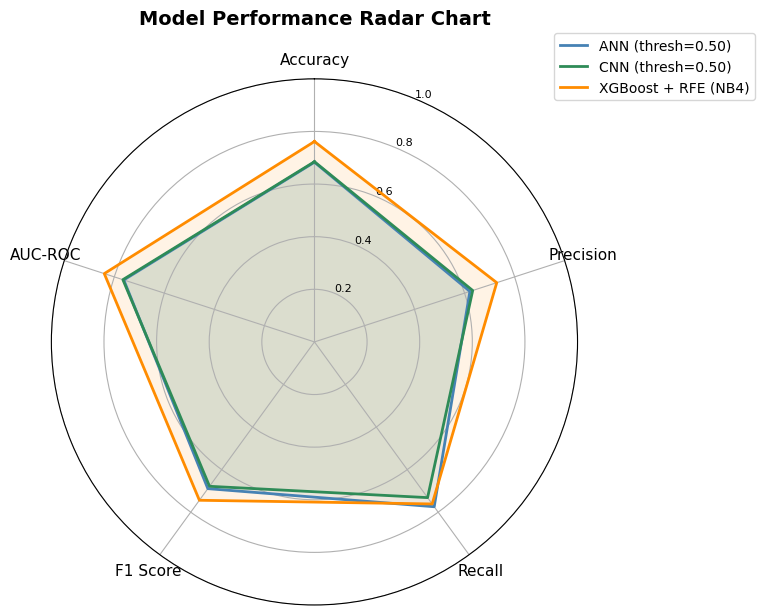

Saved: radar_comparison.png


In [47]:
# ============================================================
# 12.2 Radar Chart Comparison
# ============================================================

from matplotlib.patches import FancyArrowPatch
import matplotlib.patches as mpatches

metrics_radar = ['Accuracy', 'Precision', 'Recall', 'F1 Score', 'AUC-ROC']
num_vars = len(metrics_radar)
angles = np.linspace(0, 2 * np.pi, num_vars, endpoint=False).tolist()
angles += angles[:1]  # close the polygon

fig, ax = plt.subplots(figsize=(8, 8), subplot_kw=dict(polar=True))

plot_models = [
    ('ANN (thresh=0.50)',      colors[0]),
    ('CNN (thresh=0.50)',      colors[2]),
    ('XGBoost + RFE (NB4)',    colors[3])
]

for model_name, color in plot_models:
    row = results[results['Model'] == model_name][metrics_radar].values.flatten().tolist()
    row += row[:1]
    ax.plot(angles, row, color=color, linewidth=2, label=model_name)
    ax.fill(angles, row, color=color, alpha=0.1)

ax.set_theta_offset(np.pi / 2)
ax.set_theta_direction(-1)
ax.set_thetagrids(np.degrees(angles[:-1]), metrics_radar, fontsize=11)
ax.set_ylim(0, 1)
ax.set_yticks([0.2, 0.4, 0.6, 0.8, 1.0])
ax.set_yticklabels(['0.2', '0.4', '0.6', '0.8', '1.0'], fontsize=8)
ax.set_title('Model Performance Radar Chart',
             fontsize=14, fontweight='bold', pad=20)
ax.legend(loc='upper right', bbox_to_anchor=(1.35, 1.1), fontsize=10)

plt.tight_layout()
plt.savefig('radar_comparison.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: radar_comparison.png")


Prediction Probability Distributions


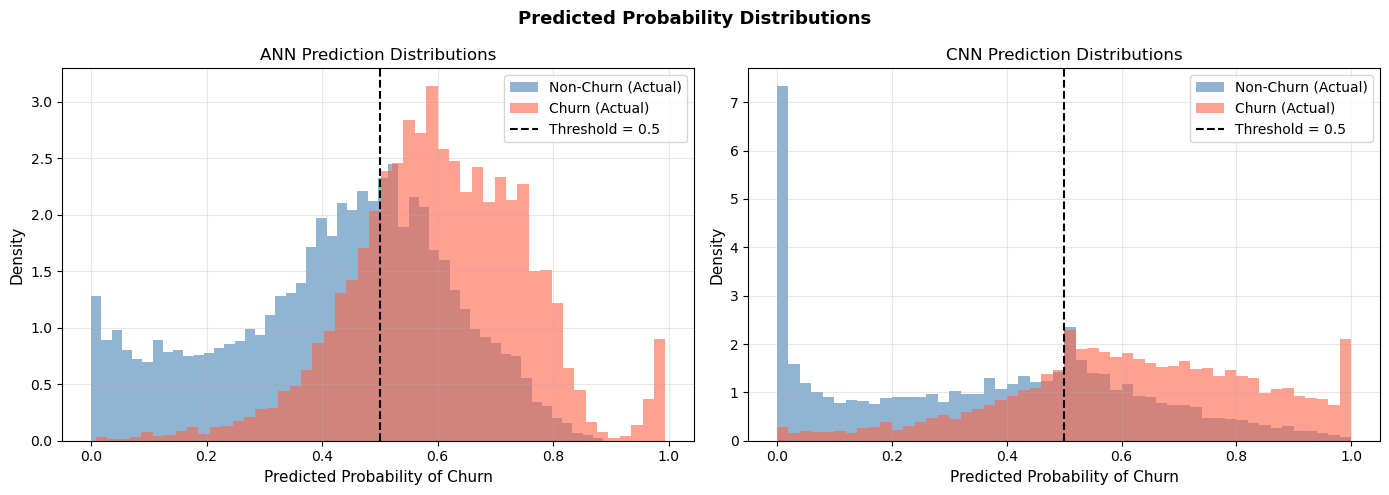

Saved: prediction_distributions.png


In [48]:
# ============================================================
# 13. Prediction Distribution Analysis
# ============================================================

print("\n" + "=" * 50)
print("Prediction Probability Distributions")
print("=" * 50)

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
fig.suptitle('Predicted Probability Distributions', fontsize=13, fontweight='bold')

for ax, (probs, name, color) in zip(
    axes,
    [(y_pred_prob_ann, 'ANN', 'steelblue'),
     (y_pred_prob_cnn, 'CNN', 'seagreen')]
):
    ax.hist(probs[y_test == 0], bins=50, alpha=0.6,
            label='Non-Churn (Actual)', color='steelblue', density=True)
    ax.hist(probs[y_test == 1], bins=50, alpha=0.6,
            label='Churn (Actual)', color='tomato', density=True)
    ax.axvline(x=0.5, color='black', linestyle='--',
               linewidth=1.5, label='Threshold = 0.5')
    ax.set_xlabel('Predicted Probability of Churn', fontsize=11)
    ax.set_ylabel('Density', fontsize=11)
    ax.set_title(f'{name} Prediction Distributions', fontsize=12)
    ax.legend()
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig('prediction_distributions.png', dpi=150, bbox_inches='tight')
plt.show()
print("Saved: prediction_distributions.png")

In [49]:
# ============================================================
# 14. Save Best Model
# ============================================================

print("\n" + "=" * 50)
print("Saving Models")
print("=" * 50)

# Save both models
ann_model.save('ann_churn_model.keras')
cnn_model.save('cnn_churn_model.keras')
print("Saved: ann_churn_model.keras")
print("Saved: cnn_churn_model.keras")

# Determine and save the best model
if auc_ann >= auc_cnn:
    best_model      = ann_model
    best_model_name = 'ANN'
    best_auc        = auc_ann
    best_model.save('best_churn_model_ann.keras')
    print(f"\nBest model: ANN (AUC = {best_auc:.4f})")
    print("Saved: best_churn_model_ann.keras")
else:
    best_model      = cnn_model
    best_model_name = 'CNN'
    best_auc        = auc_cnn
    best_model.save('best_churn_model_cnn.keras')
    print(f"\nBest model: CNN (AUC = {best_auc:.4f})")
    print("Saved: best_churn_model_cnn.keras")

# Save scaler for deployment
import joblib
joblib.dump(scaler, 'feature_scaler.pkl')
print("Saved: feature_scaler.pkl")

# Save feature column order for deployment
pd.Series(feature_names).to_csv('feature_names.csv', index=False, header=False)
print("Saved: feature_names.csv")


Saving Models
Saved: ann_churn_model.keras
Saved: cnn_churn_model.keras

Best model: CNN (AUC = 0.7656)
Saved: best_churn_model_cnn.keras
Saved: feature_scaler.pkl
Saved: feature_names.csv


In [50]:
# ============================================================
# 15. Final Summary
# ============================================================

print("\n" + "=" * 60)
print("FINAL SUMMARY")
print("=" * 60)

print(f"""
Dataset
-------
  Total samples     : {len(X)}
  Features used     : {len(feature_names)}
  Train / Test split: 80% / 20%
  Class weights     : {class_weight_dict}

ANN Results (threshold = 0.50)
-------------------------------
  Accuracy  : {acc_ann:.4f}
  Precision : {prec_ann:.4f}
  Recall    : {rec_ann:.4f}
  F1 Score  : {f1_ann:.4f}
  AUC-ROC   : {auc_ann:.4f}

ANN Results (threshold = {best_threshold:.2f}, optimised for F1)
-------------------------------
  Accuracy  : {acc_ann_opt:.4f}
  Precision : {prec_ann_opt:.4f}
  Recall    : {rec_ann_opt:.4f}
  F1 Score  : {f1_ann_opt:.4f}
  AUC-ROC   : {auc_ann:.4f}

CNN Results (threshold = 0.50)
-------------------------------
  Accuracy  : {acc_cnn:.4f}
  Precision : {prec_cnn:.4f}
  Recall    : {rec_cnn:.4f}
  F1 Score  : {f1_cnn:.4f}
  AUC-ROC   : {auc_cnn:.4f}

XGBoost + RFE (Notebook 4 reference)
--------------------------------------
  Accuracy  : {xgb_acc:.4f}
  Precision : {xgb_prec:.4f}
  Recall    : {xgb_rec:.4f}
  F1 Score  : {xgb_f1:.4f}
  AUC-ROC   : {xgb_auc:.4f}

Best Deep Learning Model : {best_model_name} (AUC = {best_auc:.4f})

Saved Artefacts
---------------
  ann_churn_model.keras
  cnn_churn_model.keras
  best_churn_model_{best_model_name.lower()}.keras
  feature_scaler.pkl
  feature_names.csv
  deep_learning_results.csv
  ann_training_curves.png
  cnn_training_curves.png
  ann_confusion_matrix.png
  cnn_confusion_matrix.png
  roc_curve_comparison.png
  ann_feature_importance.png
  ann_threshold_optimization.png
  model_comparison.png
  radar_comparison.png
  prediction_distributions.png
""")


FINAL SUMMARY

Dataset
-------
  Total samples     : 90528
  Features used     : 20
  Train / Test split: 80% / 20%
  Class weights     : {np.int64(0): np.float64(0.9158762677997825), np.int64(1): np.float64(1.1011403375399118)}

ANN Results (threshold = 0.50)
-------------------------------
  Accuracy  : 0.6831
  Precision : 0.6212
  Recall    : 0.7744
  F1 Score  : 0.6894
  AUC-ROC   : 0.7621

ANN Results (threshold = 0.43, optimised for F1)
-------------------------------
  Accuracy  : 0.6530
  Precision : 0.5764
  Recall    : 0.8896
  F1 Score  : 0.6995
  AUC-ROC   : 0.7621

CNN Results (threshold = 0.50)
-------------------------------
  Accuracy  : 0.6850
  Precision : 0.6324
  Recall    : 0.7316
  F1 Score  : 0.6784
  AUC-ROC   : 0.7656

XGBoost + RFE (Notebook 4 reference)
--------------------------------------
  Accuracy  : 0.7617
  Precision : 0.7286
  Recall    : 0.7613
  F1 Score  : 0.7440
  AUC-ROC   : 0.8400

Best Deep Learning Model : CNN (AUC = 0.7656)

Saved Artefacts